In [40]:
from dotenv import load_dotenv
load_dotenv()


from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState

In [41]:
# load the PDF document
PATH = "/home/tacktile-systems/Advance-RAG-and-Agentic-RAG/12_Agentic_RAG/documents/evs_oil_price_shock.pdf"
loader = PyPDFLoader(PATH)
raw_docs = loader.load()
print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [42]:
raw_docs[0].page_content

'Will EVs Dampen the Oil Price\n Shock?\nElectric Vehicles, Oil Demand Destruction, and the Future of Energy Price\n Volatility\n Version 1.0   |   April 2026\n Technical Reference Document'

In [43]:
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [44]:
# initialize the embedding model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [45]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_base",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
print("Vector store ready")

Vector store ready


In [46]:
# graph state
class AgenticRAGState(MessagesState):
    
    query: str
    retrieved_docs: list[Document]
    context: str
    generation: str

In [47]:
# initialize the LLM
llm = ChatOpenAI(model="gpt-4o-mini")

In [48]:
# retrieves relevant docs from the vector store
def retrieve(state: AgenticRAGState) -> dict:    
    
    docs = retriever.invoke(state["query"])
    context = "\n\n".join(doc.page_content for doc in docs)
    
    return {"retrieved_docs": docs, "context": context}

In [49]:
def generate(state: AgenticRAGState):
    query = state["query"]
    context = state.get("context")

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
        ("human", "{query}"),
    ])

    response = (prompt_template | llm).invoke({"context": context, "query": query})

    return {"generation": response.content}

In [50]:


# build the graph: START -> retrieve -> generate -> END
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)



In [51]:
graph = graph_builder.compile()

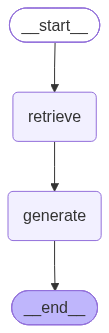

In [52]:
graph

In [53]:
test_query = "How will EVS impact oil demand in the next decade?"
result = graph.invoke({"query": test_query, "messages": []})

In [54]:
print("=== GENERATED RESPONSE ===")
print(result["generation"])

=== GENERATED RESPONSE ===
EVs are projected to account for between 40 and 60 percent of new vehicle sales globally by 2030, which will significantly increase the stock of EVs on the road from roughly 40 million today to between 300 and 500 million by the early 2030s. This growth in EVs is expected to have a material impact on oil demand, as the electrification of passenger and light commercial vehicles will influence global oil dynamics. However, heavy trucking, aviation, shipping, and petrochemical feedstock demand, which collectively make up about 43 percent of oil consumption, are not the primary focus of this analysis. The central question is whether the adoption of EVs will be sufficient to materially alter the oil price formation process.


In [58]:
print("\n=== RETRIEVED DOCUMENTS ===")
for i, doc in enumerate(result["retrieved_docs"], 1):
    source = doc.metadata.get("source", "unknown")
    page = doc.metadata.get("page", "?")
    snippet = doc.page_content[:500].replace("\n", " ")
    print(f"[{i}] Source: {source} | Page: {page}")
    print(f"    {snippet}...")


=== RETRIEVED DOCUMENTS ===
[1] Source: /home/tacktile-systems/Advance-RAG-and-Agentic-RAG/12_Agentic_RAG/documents/evs_oil_price_shock.pdf | Page: 3
    Energy Agency, and McKinsey collectively project that EVs will account for between 40 and 60 percent of new vehicle sales globally by 2030. The stock of EVs on the road — which matters more than annual sales for oil displacement — is projected to grow from roughly 40 million vehicles today to between 300 and 500 million by the early 2030s. Whether this is sufficient to materially alter the oil price formation process is the central question this report addresses. 1.1 Scope and Methodology  This ...
[2] Source: /home/tacktile-systems/Advance-RAG-and-Agentic-RAG/12_Agentic_RAG/documents/evs_oil_price_shock.pdf | Page: 3
    Energy Agency, and McKinsey collectively project that EVs will account for between 40 and 60 percent of new vehicle sales globally by 2030. The stock of EVs on the road — which matters more than annual sales for oil

In [60]:
print(result["context"])

Energy Agency, and McKinsey collectively project that EVs will account for between 40 and
60 percent of new vehicle sales globally by 2030. The stock of EVs on the road — which
matters more than annual sales for oil displacement — is projected to grow from roughly 40
million vehicles today to between 300 and 500 million by the early 2030s. Whether this is
sufficient to materially alter the oil price formation process is the central question this report
addresses.
1.1 Scope and Methodology
 This report focuses on the relationship between passenger and light commercial vehicle
electrification and global oil demand dynamics. Heavy trucking, aviation, shipping, and
petrochemical feedstock demand — which collectively account for roughly 43 percent of oil
consumption — are not the primary subject of analysis, though their trajectories are

Energy Agency, and McKinsey collectively project that EVs will account for between 40 and
60 percent of new vehicle sales globally by 2030. The stock of E